In [32]:
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [33]:
titanic = sns.load_dataset("titanic")
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

#handle missing data 
imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

#encode
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X =titanic[features]
y = titanic["survived"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.3,random_state = 42
)

In [34]:
#decision tree
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy",accuracy_score(y_train,y_pred_train))
print("testing accuracy",accuracy_score(y_test,y_pred_test))

Training accuracy 0.9791332263242376
testing accuracy 0.7686567164179104


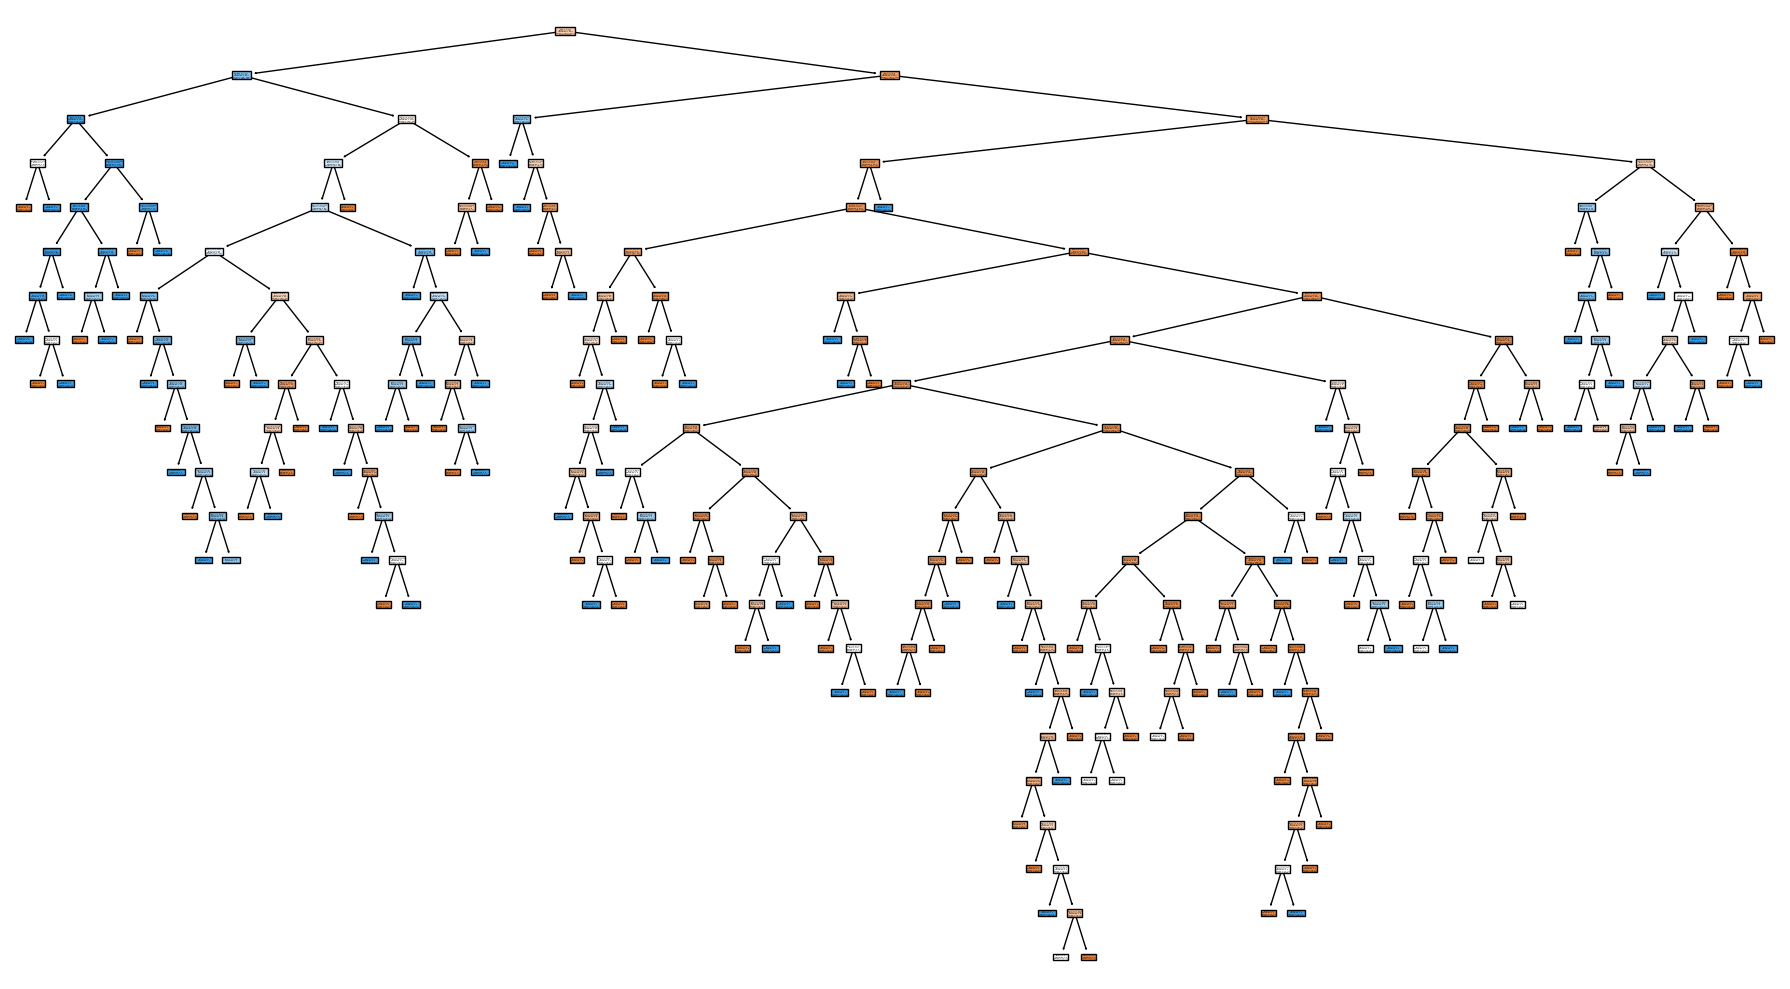

In [35]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True
)
plt.tight_layout()

In [36]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators = 501,
    oob_score = True
)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print("oob  score",rf.oob_score_ * 100 ,"%")
print("testing accuracy",accuracy_score(y_test,y_pred) * 100 ,"%")

oob  score 81.54093097913324 %
testing accuracy 77.98507462686567 %


In [38]:
#Bagging classifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)
bagging.fit(X_train,y_train)
y_pred = bagging.predict(X_test)
print("accuracy",accuracy_score(y_test,y_pred))

accuracy 0.7723880597014925
